# YOLOv13-S Baseline - AFB / Tuberculosis6208 (Chen split)

Mirror struktur `yolo12.ipynb` (wavelet-yolo12) supaya **apples-to-apples** vs YOLOv12s baseline.

**Setup:**
- Dataset zip di Drive: `MyDrive/Tuberculosis6208.zip` (Pascal-VOC).
- Split: **Chen et al. IJAI 2024** - 1024/140/101, `SPLIT_SEED=42` deterministic.
- Training: 1 run, `MODEL=yolov13s`, `SEED=42`, 60 epoch.
- Logging: **W&B** - project `afb_yolov13_chen`.
- Runtime: A100 ~ 25-30 menit per run.

Notebook portable Colab + local Windows (cells Colab-only auto-skip jika tidak terdeteksi).

## 0. Environment detection

In [1]:
import sys
IS_COLAB = 'google.colab' in sys.modules
print('Environment :', 'Colab' if IS_COLAB else 'local')

Environment : Colab


In [ ]:
import os
os.kill(os.getpid(), 9)

## 1. Mount Drive (Colab only)

In [2]:
if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
else:
    print('skip: not Colab')

Mounted at /content/drive


## 2. Clone repo (afb-yolo13) + YOLOv13 fork

**Colab:** clone fresh ke `/content/`. Cleanup cache supaya tidak konflik dgn previous run.

**Local:** asumsi `D:/Project/afb-yolo13` dan `D:/Project/yolov13` sudah ada.

In [3]:
# =========================
# COLAB CLEAN + HARD RELOAD REPO
# =========================

import os, sys, gc, shutil, importlib
from pathlib import Path
import torch

IS_COLAB = os.path.exists("/content")

if IS_COLAB:
    REPO_DIR    = Path("/content/afb-yolo13")
    YOLOV13_DIR = Path("/content/yolov13")

    # =========================
    # 1. Clear RAM / GPU cache
    # =========================
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

    # =========================
    # 2. Remove Python cache
    # =========================
    !find /content -type d -name "__pycache__" -exec rm -rf {} + 2>/dev/null
    !find /content -type f -name "*.pyc" -delete 2>/dev/null
    !find /content -type f -name "*.pyo" -delete 2>/dev/null

    # =========================
    # 3. Remove pip / ultralytics cache
    # =========================
    !pip cache purge -q
    !rm -rf ~/.cache/ultralytics ~/.config/Ultralytics /root/.cache/ultralytics 2>/dev/null

    # =========================
    # 4. Clone / hard reset afb-yolo13
    # =========================
    if REPO_DIR.exists():
        !cd {REPO_DIR} && git fetch origin
        !cd {REPO_DIR} && git checkout main
        !cd {REPO_DIR} && git reset --hard origin/main
        !cd {REPO_DIR} && git clean -fd
    else:
        !git clone https://github.com/iswantosan/afb-yolo13.git {REPO_DIR}

    # =========================
    # 5. Clone / hard reset yolov13
    # =========================
    if YOLOV13_DIR.exists():
        !cd {YOLOV13_DIR} && git fetch origin
        !cd {YOLOV13_DIR} && git checkout main
        !cd {YOLOV13_DIR} && git reset --hard origin/main
        !cd {YOLOV13_DIR} && git clean -fd
    else:
        !git clone https://github.com/iMoonLab/yolov13.git {YOLOV13_DIR}

    # =========================
    # 6. Remove loaded modules from current Python session
    # =========================
    remove_prefixes = [
        "ultralytics",
        "yolo",
        "models",
        "utils",
        "engine",
        "nn",
        "data",
        "cfg",
        "afb",
        "train",
        "val",
        "predict",
    ]

    for name in list(sys.modules.keys()):
        if any(name == p or name.startswith(p + ".") for p in remove_prefixes):
            del sys.modules[name]

    importlib.invalidate_caches()

    # =========================
    # 7. Fix sys.path priority
    # YOLOV13 first, then your repo
    # =========================
    for p in [str(REPO_DIR), str(YOLOV13_DIR)]:
        if p in sys.path:
            sys.path.remove(p)

    sys.path.insert(0, str(REPO_DIR))
    sys.path.insert(0, str(YOLOV13_DIR))

    os.chdir(YOLOV13_DIR)

    print("DONE CLEAN + RESET")
    print("cwd:", os.getcwd())
    print("sys.path[0]:", sys.path[0])
    print("sys.path[1]:", sys.path[1])

    print("\nafb-yolo13 latest commit:")
    !cd {REPO_DIR} && git log -1 --oneline

    print("\nyolov13 latest commit:")
    !cd {YOLOV13_DIR} && git log -1 --oneline

else:
    REPO_DIR    = Path("D:/Project/afb-yolo13")
    YOLOV13_DIR = Path("D:/Project/yolov13")

    print("Local repos:")
    print("  REPO_DIR    :", REPO_DIR, "(exists)" if REPO_DIR.exists() else "(MISSING)")
    print("  YOLOV13_DIR :", YOLOV13_DIR, "(exists)" if YOLOV13_DIR.exists() else "(MISSING)")

Cloning into '/content/afb-yolo13'...
remote: Enumerating objects: 221, done.
remote: Counting objects: 100% (221/221), done.
remote: Compressing objects: 100% (139/139), done.
remote: Total 221 (delta 116), reused 134 (delta 57), pack-reused 0 (from 0)
Receiving objects: 100% (221/221), 248.67 KiB | 7.31 MiB/s, done.
Resolving deltas: 100% (116/116), done.
Cloning into '/content/yolov13'...
remote: Enumerating objects: 527, done.
remote: Counting objects: 100% (296/296), done.
remote: Compressing objects: 100% (177/177), done.
remote: Total 527 (delta 136), reused 119 (delta 119), pack-reused 231 (from 3)
Receiving objects: 100% (527/527), 29.91 MiB | 36.12 MiB/s, done.
Resolving deltas: 100% (160/160), done.
DONE CLEAN + RESET
cwd: /content/yolov13
sys.path[0]: /content/yolov13
sys.path[1]: /content/afb-yolo13

afb-yolo13 latest commit:
fa38c1c (HEAD -> main, origin/main, origin/HEAD) Created using Colab

yolov13 latest commit:
7328994 (HEAD -> main, origin/main, origin/HEAD) Update 

## 3. Install dependencies + apply L3 patches

Patch script copies custom AFB modules (RodDSC3k2, SpatialFullPAD_Tunnel, HyperACEScale, etc.) ke YOLOv13 source tree. Idempotent — skip kalau sudah ter-patch. Buat backup `.orig` di first apply.

In [4]:
if IS_COLAB:
    # 1. Apply AFB-YOLOv13 patches FIRST (before pip install -e)
    !python {REPO_DIR}/scripts/apply_yolov13_patches.py {YOLOV13_DIR}
    # 2. Install YOLOv13 editable + wandb
    !pip -q install -e {YOLOV13_DIR} wandb
    !pip -q install -r {REPO_DIR}/requirements.txt
    # 3. (Optional) Install mamba-ssm for Mamba variant. Skip-if-fail safe.
    print('\n[Optional] Installing mamba-ssm for Mamba variant...')
    !pip -q install causal-conv1d>=1.4.0 mamba-ssm>=2.2.0 2>&1 | tail -5 || echo "[warn] mamba-ssm install failed; Mamba variant will use fallback Conv1d"
else:
    print('Local: pastikan sudah jalankan:')
    print(f'  python {REPO_DIR}/scripts/apply_yolov13_patches.py {YOLOV13_DIR}')
    print(f'  pip install -e {YOLOV13_DIR}')
    print(f'  pip install -r {REPO_DIR}/requirements.txt')
    print(f'  (optional) pip install causal-conv1d mamba-ssm  # for Mamba variant')

Applying AFB-YOLOv13 patches to: /content/yolov13
  [backup] ultralytics/nn/modules/block.py -> block.py.orig
  [done] patched ultralytics/nn/modules/block.py
  [backup] ultralytics/nn/modules/__init__.py -> __init__.py.orig
  [done] patched ultralytics/nn/modules/__init__.py
  [backup] ultralytics/nn/tasks.py -> tasks.py.orig
  [done] patched ultralytics/nn/tasks.py
  [backup] ultralytics/utils/loss.py -> loss.py.orig
  [done] patched ultralytics/utils/loss.py
  [backup] ultralytics/cfg/default.yaml -> default.yaml.orig
  [done] patched ultralytics/cfg/default.yaml
  [backup] ultralytics/cfg/__init__.py -> __init__.py.orig
  [done] patched ultralytics/cfg/__init__.py

Patched 6 file(s). Reinstall YOLOv13:
    pip install -e /content/yolov13
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for ultralytics (pyp

## 4. Build dataset split

Pilih mode via variable `SPLIT_MODE`:
- `"single"` — 80/10/10 train/val/test (proper standard split, deterministic seed=42)
- `"5fold"` — 5-fold cross-validation (each image in val of exactly 1 fold, no separate test)

5-fold mode = standard untuk medical imaging paper. Reviewer Q2 di MDPI/Sensors/Symmetry biasanya expect ini.

In [ ]:
# === Pilih dataset + mode split ===
DATASET    = "tb6208"        # "tb6208" (Tuberculosis6208 VOC) | "raw_sputum" (pre-split YOLO)
SPLIT_MODE = "single"        # "single" atau "5fold" (ignored kalo dataset pre-split)
SPLIT_SEED = 42

# Per-dataset config. format: "voc" -> butuh build_split.py | "yolo_presplit" -> unzip aja
DATASET_CONFIG = {
    "tb6208": dict(
        drive_zip="/content/drive/MyDrive/Tuberculosis6208.zip",
        local_src="D:/project/yolov12/Tuberculosis6208/tuberculosis-phonecamera",
        extract_subdir="tuberculosis-phonecamera",
        label_names=["TBbacillus"],
        format="voc",
    ),
    "raw_sputum": dict(
        drive_zip="/content/drive/MyDrive/Raw_Sputum_Microscopy_Dataset.zip",
        local_src=None,
        extract_subdir=".",          # zip langsung extract ke root (images/ + labels/)
        label_names=None,
        format="yolo_presplit",
    ),
}
cfg = DATASET_CONFIG[DATASET]
DATA_FORMAT = cfg["format"]

if IS_COLAB:
    DRIVE_ZIP   = cfg["drive_zip"]
    EXTRACT_DIR = f"/content/dataset/raw_{DATASET}"
    DATASET_SRC = (EXTRACT_DIR if cfg["extract_subdir"] == "."
                   else f'{EXTRACT_DIR}/{cfg["extract_subdir"]}')
else:
    DRIVE_ZIP   = None
    EXTRACT_DIR = None
    DATASET_SRC = cfg["local_src"]

LABEL_NAMES = cfg["label_names"]

SPLIT_DIR = (f"/content/{DATASET}_{SPLIT_MODE}_seed{SPLIT_SEED}" if IS_COLAB
             else f"D:/datasets/{DATASET}_{SPLIT_MODE}_seed{SPLIT_SEED}")

if DATA_FORMAT == "yolo_presplit":
    # Pre-split YOLO format — unzip + tulis data.yaml. SPLIT_MODE diabaikan.
    import zipfile
    if IS_COLAB and not Path(EXTRACT_DIR).exists():
        if not Path(DRIVE_ZIP).exists():
            raise FileNotFoundError(f"Zip tidak ada di Drive: {DRIVE_ZIP}")
        print(f"Extracting {DRIVE_ZIP} -> {EXTRACT_DIR}")
        Path(EXTRACT_DIR).mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(DRIVE_ZIP) as zf:
            zf.extractall(EXTRACT_DIR)
    Path(SPLIT_DIR).mkdir(parents=True, exist_ok=True)
    yaml_body = f"""path: {DATASET_SRC}
train: images/train
val: images/val
test: images/test
nc: 1
names:
  0: bacilli
"""
    yaml_path = Path(SPLIT_DIR) / "data.yaml"
    yaml_path.write_text(yaml_body)
    DATA_YAMLS = [str(yaml_path)]
    print(f"Wrote {yaml_path}")

elif DATA_FORMAT == "voc":
    # Pascal-VOC -> butuh build_split.py untuk konversi + split
    marker = Path(SPLIT_DIR) / ("data.yaml" if SPLIT_MODE == "single" else "fold_0/data.yaml")
    if not marker.exists():
        cmd_parts = [
            "python", f"{REPO_DIR}/scripts/build_split.py",
            "--src", f'"{DATASET_SRC}"',
            "--out", f'"{SPLIT_DIR}"',
            "--mode", SPLIT_MODE,
            "--seed", str(SPLIT_SEED),
        ]
        for ln in LABEL_NAMES:
            cmd_parts += ["--label-name", ln]
        if DRIVE_ZIP and Path(DRIVE_ZIP).exists():
            cmd_parts += ["--zip", f'"{DRIVE_ZIP}"', "--extract-dir", f'"{EXTRACT_DIR}"']
        cmd = " ".join(cmd_parts)
        print(cmd)
        os.system(cmd)
    else:
        print(f"Split already exists at {SPLIT_DIR}")
    if SPLIT_MODE == "single":
        DATA_YAMLS = [str(Path(SPLIT_DIR) / "data.yaml")]
    else:
        DATA_YAMLS = sorted(str(p) for p in Path(SPLIT_DIR).glob("fold_*/data.yaml"))
else:
    raise ValueError(f"Unknown DATA_FORMAT: {DATA_FORMAT}")

print(f"Dataset: {DATASET}  Format: {DATA_FORMAT}  Mode: {SPLIT_MODE}  Folds/Splits: {len(DATA_YAMLS)}")
print("First yaml:")
print(Path(DATA_YAMLS[0]).read_text())

## 5. W&B login

In [6]:
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 1


wandb: You chose 'Create a W&B account'
wandb: Create an account here: https://wandb.ai/authorize?signup=true&ref=models
wandb: After creating your account, create a new API key and store it securely.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: is-san86 (is-san86-binus) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 6. Config run

Ganti `MODEL_CFG` untuk varian:

**Baseline (Ultralytics stock):**
- `yolov13n.yaml` / `yolov13s.yaml` / `yolov13l.yaml` / `yolov13x.yaml`

**L1 hyperparam tweak (bukan novelty):**

| YAML | Strategy | Status |
|---|---|---|
| `yolov13s-fine.yaml` | head DSC3k2 k2=5 | 🟡 |
| `yolov13s-he16.yaml` | HyperACE num_hyperedges 8→16 | 🟡 |

**L2 connectivity (risky):**

| YAML | Status |
|---|---|
| `yolov13s-p2.yaml` | ✗ broke gates #6/#7 |

**L3 new module (engineering):**

| YAML | Module |
|---|---|
| `yolov13s-rod.yaml` | RodDSC3k2 |
| `yolov13s-spgate.yaml` | SpatialFullPAD_Tunnel |
| `yolov13s-scfuse.yaml` | HyperACEScale |

**L4 — HyperMIL (real novelty, image-level supervision):**

| Aktivasi | Cara |
|---|---|
| `USE_HYPERMIL = True` di cell ini + base yaml apa pun | Tambah aux MIL head + count loss tanpa ubah YAML |

HyperMIL: hypergraph-backed MIL aux head reading from HyperACE output. Target: label noise (66% far FP yang ternyata mostly real bacilli). Image-level count loss memaksa model discover all bacilli, bukan hanya GT-marked subset.

Run name auto = `<stem>_seed<S>_<EP>ep`, plus `_mil` suffix kalau HyperMIL aktif.

In [7]:
# Pilih satu (uncomment yang mau dijalankan):
# === baseline ===
MODEL_CFG = 'yolo11s.yaml'                                         # baseline
# === L1 / L3 variants ===
#MODEL_CFG = str(REPO_DIR / 'configs' / 'yolov11.yaml')
# MODEL_CFG = str(REPO_DIR / 'configs' / 'yolov13s-he16.yaml')
# MODEL_CFG = str(REPO_DIR / 'configs' / 'yolov13s-rod.yaml')
# MODEL_CFG = str(REPO_DIR / 'configs' / 'yolov13s-spgate.yaml')
# MODEL_CFG = str(REPO_DIR / 'configs' / 'yolov13s-scfuse.yaml')

# === L4 HyperMIL toggle ===
USE_HYPERMIL    = False       # set True to enable HyperMIL aux head + count loss
MIL_WEIGHT      = 0.5         # weight for MIL count loss term
MIL_HIDDEN      = 128         # hidden dim for attention pooling + MLP
CONSIST_WEIGHT  = 0.0         # detection-MIL consistency regularizer (0 = off)

PRETRAINED    = 'yolov11s.pt'        # selalu yolov11s.pt (auto-download iMoonLab)
SEED          = 42
EPOCHS        = 60
IMGSZ         = 640
BATCH         = 16
DEVICE        = 0

WANDB_PROJECT = 'afb_yolov11_chen'
RUN_PROJECT   = '/content/runs/afb_yolov11' if IS_COLAB else 'D:/runs/afb_yolov13'
RUN_NAME      = f"{Path(MODEL_CFG).stem}_seed{SEED}_{EPOCHS}ep"
if USE_HYPERMIL:
    RUN_NAME += f'_mil{MIL_WEIGHT:g}'
    if CONSIST_WEIGHT > 0:
        RUN_NAME += f'_c{CONSIST_WEIGHT:g}'

print('cfg          :', MODEL_CFG)
print('seed         :', SEED)
print('epochs       :', EPOCHS)
print('USE_HYPERMIL :', USE_HYPERMIL, f'(weight={MIL_WEIGHT}, hidden={MIL_HIDDEN})' if USE_HYPERMIL else '')
print('run_name     :', RUN_NAME)
print('project      :', RUN_PROJECT)

cfg          : yolo11s.yaml
seed         : 42
epochs       : 60
USE_HYPERMIL : False 
run_name     : yolo11s_seed42_60ep
project      : /content/runs/afb_yolov11


## 7. Seed + SDP kernel + W&B init

In [8]:
import random, numpy as np

# Stable SDP kernel (avoid Flash/MEM-efficient mismatch)
os.environ['PYTORCH_SDP_KERNEL'] = 'math'
torch.backends.cuda.enable_flash_sdp(False)
torch.backends.cuda.enable_mem_efficient_sdp(False)
torch.backends.cuda.enable_math_sdp(True)

# Seed (per fold akan di-reseed di train loop)
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

# Disable Ultralytics built-in W&B callback (we log per-fold manually)
from ultralytics.utils import SETTINGS
SETTINGS.update({'wandb': False})

print(f'Seed: {SEED}  SDP kernel: math (stable)')
print(f'W&B init akan dibuat per-fold di cell training berikutnya.')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/yolov13/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
FlashAttention is not available on this device. Using scaled_dot_product_attention instead.
Seed: 42  SDP kernel: math (stable)
W&B init akan dibuat per-fold di cell training berikutnya.


## 8. Auto-download pretrained yolov13s.pt

In [9]:
from urllib.request import urlretrieve

pt = Path(PRETRAINED)
if not pt.exists():
    url = f'https://github.com/ultralytics/assets/releases/download/v8.3.0/yolo11s.pt'
    print(f'Downloading {url}')
    urlretrieve(url, pt)
print(f'Pretrained: {pt}  ({pt.stat().st_size/1e6:.1f} MB)')

Pretrained: yolov11s.pt  (19.3 MB)


## 9. Train - `model.train()` eksplisit (mirror yolo12.ipynb hyperparams)

In [18]:
import time
from ultralytics import YOLO

# === Training loop over folds (or single split) ===
# Each fold trains a fresh model from PRETRAINED, evals on its own val split.
# All folds logged to W&B as separate runs (grouped by RUN_NAME for 5fold).

fold_results = []   # list of dict per fold with metrics
all_save_dirs = []
NWD_RATIO = 0.0
NWD_C = 12.5
for fold_idx, fold_yaml in enumerate(DATA_YAMLS):
    n_folds = len(DATA_YAMLS)
    is_kfold = SPLIT_MODE == '5fold'

    fold_run_name = f'{RUN_NAME}_fold{fold_idx}' if is_kfold else RUN_NAME
    fold_train_dir = f'{fold_run_name}_train'

    # Re-seed per fold (same SEED for reproducibility; randomness comes from fold data)
    random.seed(SEED); np.random.seed(SEED)
    torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

    print('\n' + '=' * 70)
    print(f'  FOLD {fold_idx+1}/{n_folds}: {fold_run_name}')
    print(f'  data.yaml: {fold_yaml}')
    print('=' * 70)

    # W&B per fold
    fold_run = wandb.init(
        project=WANDB_PROJECT,
        name=fold_run_name,
        group=RUN_NAME if is_kfold else None,
        reinit=True,
        config=dict(
            model_cfg=MODEL_CFG, data_yaml=fold_yaml, pretrained=PRETRAINED,
            seed=SEED, epochs=EPOCHS, imgsz=IMGSZ, batch=BATCH,
            optimizer='SGD', lr0=0.01, momentum=0.937, cos_lr=True,
            split_mode=SPLIT_MODE, split_seed=SPLIT_SEED,
            fold_idx=fold_idx, n_folds=n_folds,
            nwd_ratio=NWD_RATIO, nwd_c=NWD_C,
            use_hypermil=USE_HYPERMIL, mil_weight=MIL_WEIGHT if USE_HYPERMIL else 0.0,
        ),
        tags=[Path(MODEL_CFG).stem, f'seed{SEED}', SPLIT_MODE,
              f'fold{fold_idx}'] + ([f'nwd{NWD_RATIO}'] if NWD_RATIO > 0 else []),
    )
    print(f'  W&B: {fold_run.url}')

    # Fresh model + pretrained per fold
    model = YOLO(MODEL_CFG)
    try:
        model.load(PRETRAINED)
        print(f'  Loaded pretrained: {PRETRAINED}')
    except Exception as e:
        print(f'  [warn] could not load pretrained: {e}')

    # HyperMIL callback (still WIP; not recommended for now)
    if USE_HYPERMIL:
        sys.path.insert(0, str(REPO_DIR))
        from afb_yolov13 import make_hypermil_callback
        model.add_callback(
            'on_pretrain_routine_start',
            make_hypermil_callback(mil_weight=MIL_WEIGHT, mil_hidden=MIL_HIDDEN,
                                   consist_weight=CONSIST_WEIGHT),
        )

    # Train
    t0 = time.time()
    results = model.train(
        data=str(fold_yaml),
        freeze=2,
        epochs=EPOCHS,
        imgsz=IMGSZ,
        batch=BATCH,
        device=DEVICE,
        optimizer='SGD',
        lr0=0.01, lrf=0.01,
        momentum=0.937, weight_decay=0.0005,
        #cos_lr=True,
        nwd_ratio=NWD_RATIO,
        nwd_c=NWD_C,
        # close_mosaic=10,
        # hsv_h=0.1, hsv_s=0.3, hsv_v=0.3,
        # degrees=30, translate=0.05, scale=0.1,
        # flipud=0.3,
        # mosaic=0.2, mixup=0.2,
        patience=0,
        amp=True,
        deterministic=True,
        seed=SEED,
        workers=8,
        project=RUN_PROJECT,
        name=fold_train_dir,
        exist_ok=True, save=True, verbose=True,
    )
    train_secs = time.time() - t0
    print(f'\n  Fold {fold_idx} train time: {train_secs/60:.1f} min')
    print(f'  Save dir            : {results.save_dir}')
    all_save_dirs.append(results.save_dir)

    # Eval di val split fold ini (gak ada test split di kfold mode)
    best_pt = Path(results.save_dir) / 'weights' / 'best.pt'
    eval_split = 'test' if SPLIT_MODE == 'single' else 'val'
    eval_model = YOLO(str(best_pt))
    eva = eval_model.val(data=str(fold_yaml), split=eval_split,
                         imgsz=IMGSZ, device=DEVICE, verbose=False)

    map50   = float(eva.box.map50)
    map5095 = float(eva.box.map)
    precision = float(np.mean(np.atleast_1d(eva.box.p)))
    recall    = float(np.mean(np.atleast_1d(eva.box.r)))

    map_at_09 = float('nan')
    try:
        ap_all = eva.box.all_ap
        if ap_all is not None and len(ap_all):
            ap = (ap_all.mean(axis=0) if (hasattr(ap_all, 'ndim') and ap_all.ndim == 2)
                  else ap_all)
            if len(ap) >= 9: map_at_09 = float(ap[8])
    except Exception:
        pass

    fold_m = dict(
        fold=fold_idx,
        eval_split=eval_split,
        mAP50=map50, mAP50_95=map5095, mAP_at_09=map_at_09,
        precision=precision, recall=recall,
        train_min=train_secs / 60,
        save_dir=str(results.save_dir),
    )
    fold_results.append(fold_m)

    print(f'\n  === FOLD {fold_idx} RESULTS ({eval_split}) ===')
    print(f'    mAP50    : {map50:.4f}')
    print(f'    mAP50-95 : {map5095:.4f}')
    print(f'    mAP@0.9  : {map_at_09:.4f}')
    print(f'    P / R    : {precision:.4f} / {recall:.4f}')

    # Log fold summary to W&B
    fold_run.summary[f'{eval_split}/mAP50']      = map50
    fold_run.summary[f'{eval_split}/mAP50-95']   = map5095
    fold_run.summary[f'{eval_split}/mAP@0.9']    = map_at_09
    fold_run.summary[f'{eval_split}/precision']  = precision
    fold_run.summary[f'{eval_split}/recall']     = recall
    fold_run.summary['train/time_min']           = train_secs / 60
    fold_run.summary['fold_idx']                 = fold_idx

    # Upload per-fold plots
    for img in Path(results.save_dir).glob('*.png'):
        tag = img.stem.lower()
        if any(t in tag for t in ('results', 'confusion', 'f1_curve',
                                  'pr_curve', 'p_curve', 'r_curve')):
            try:
                fold_run.log({f'plots/{img.stem}': wandb.Image(str(img))})
            except Exception:
                pass

    fold_run.finish()
    print(f'  W&B fold {fold_idx} finalised.')

print('\n' + '=' * 70)
print(f'  ALL {len(DATA_YAMLS)} FOLD(S) DONE')
print('=' * 70)


  FOLD 1/1: yolo11s_seed42_60ep
  data.yaml: /content/tb_single_seed42/data.yaml


  W&B: https://wandb.ai/is-san86-binus/afb_yolov11_chen/runs/citck5a6
Transferred 499/499 items from pretrained weights
  Loaded pretrained: yolov11s.pt
New https://pypi.org/project/ultralytics/8.4.62 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.63 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: task=detect, mode=train, model=yolo11s.yaml, data=/content/tb_single_seed42/data.yaml, epochs=60, time=None, patience=0, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=/content/runs/afb_yolov11, name=yolo11s_seed42_60ep_train, exist_ok=True, pretrained=yolov11s.pt, optimizer=SGD, verbose=True, seed=42, deterministic=True, single_cls=False, rect=False, cos_lr=True, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=2, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, ma

train: Scanning /content/tb_single_seed42/train/labels.cache... 1012 images, 36 backgrounds, 0 corrupt: 100%|██████████| 1012/1012 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8)), ImageCompression(p=0.5, compression_type='jpeg', quality_range=(75, 100))



val: Scanning /content/tb_single_seed42/val/labels.cache... 126 images, 8 backgrounds, 0 corrupt: 100%|██████████| 126/126 [00:00<?, ?it/s]


...

                   all        126       1064      0.766      0.743      0.841      0.366      0.428
Speed: 0.1ms preprocess, 0.9ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /content/runs/afb_yolov11/yolo11s_seed42_60ep_train

  Fold 0 train time: 9.4 min
  Save dir            : /content/runs/afb_yolov11/yolo11s_seed42_60ep_train
Ultralytics 8.3.63 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO11s summary (fused): 238 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs


val: Scanning /content/tb_single_seed42/test/labels.cache... 127 images, 3 backgrounds, 0 corrupt: 100%|██████████| 127/127 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50      mAP75  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.35it/s]


                   all        127       1061      0.799      0.802      0.878      0.377      0.451
Speed: 0.1ms preprocess, 1.2ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to /content/yolov13/runs/detect/val5

  === FOLD 0 RESULTS (test) ===
    mAP50    : 0.8783
    mAP50-95 : 0.4507
    mAP@0.9  : 0.0059
    P / R    : 0.7994 / 0.8021


fold_idx,0
test/mAP50,0.87833
test/mAP50-95,0.45069
test/mAP@0.9,0.00591
test/precision,0.79944
test/recall,0.80207
train/time_min,9.38004


  W&B fold 0 finalised.

  ALL 1 FOLD(S) DONE


## (Removed) Per-epoch curve cell

Per-epoch metrics dari `results.csv` sekarang di-handle per-fold di cell training di atas. Cell ini di-skip — biarkan default Ultralytics save CSV ke `runs/`.

In [ ]:
# Per-epoch curve logging dipindahkan ke training loop (per-fold via results.csv).
# Cell ini sengaja kosong supaya numbering selanjutnya tidak berubah.
print('(per-epoch curves: lihat results.csv di setiap save_dir per fold)')
for fr in fold_results:
    print(f'  fold {fr["fold"]}: {Path(fr["save_dir"]) / "results.csv"}')

(per-epoch curves: lihat results.csv di setiap save_dir per fold)
  fold 0: /content/runs/afb_yolov11/yolo11s-spd_seed42_60ep_train/results.csv


## 11. Aggregate metrics across folds (mean ± std) + log summary ke W&B

In [ ]:
import json

print('\n' + '=' * 70)
print(f'  AGGREGATE — {len(fold_results)} fold(s)')
print('=' * 70)

metrics_keys = ['mAP50', 'mAP50_95', 'mAP_at_09', 'precision', 'recall', 'train_min']
agg = {}
for k in metrics_keys:
    vals = np.array([m[k] for m in fold_results if not np.isnan(m[k])])
    if len(vals) > 0:
        agg[k] = dict(mean=float(np.mean(vals)), std=float(np.std(vals)),
                      values=[float(v) for v in vals])

# Tabel ringkas
print(f"\n  {'Metric':<14} {'Mean':>10} {'Std':>10}  {'Per-fold values'}")
print('  ' + '-' * 60)
for k in metrics_keys:
    if k not in agg:
        continue
    vals_str = '  '.join(f'{v:.4f}' for v in agg[k]['values'])
    print(f"  {k:<14} {agg[k]['mean']:>10.4f} {agg[k]['std']:>10.4f}  [{vals_str}]")

# Log summary run ke W&B
print('\n  Logging aggregate run to W&B...')
agg_run = wandb.init(
    project=WANDB_PROJECT,
    name=f'{RUN_NAME}_AGG',
    group=RUN_NAME if SPLIT_MODE == '5fold' else None,
    reinit=True,
    config=dict(
        model_cfg=MODEL_CFG, pretrained=PRETRAINED, seed=SEED,
        epochs=EPOCHS, imgsz=IMGSZ, batch=BATCH,
        split_mode=SPLIT_MODE, n_folds=len(fold_results),
        nwd_ratio=NWD_RATIO, nwd_c=NWD_C,
    ),
    tags=[Path(MODEL_CFG).stem, f'seed{SEED}', SPLIT_MODE, 'aggregate'],
)
for k, v in agg.items():
    agg_run.summary[f'{k}/mean'] = v['mean']
    agg_run.summary[f'{k}/std']  = v['std']
    for i, val in enumerate(v['values']):
        agg_run.summary[f'{k}/fold{i}'] = val
agg_run.summary['n_folds'] = len(fold_results)
agg_run.finish()
print(f'  W&B aggregate run finalised: {RUN_NAME}_AGG')

# Save local JSON for paper / reference
agg_path = Path(all_save_dirs[0]).parent / f'{RUN_NAME}_aggregate.json'
agg_path.write_text(json.dumps(
    dict(run_name=RUN_NAME, model_cfg=MODEL_CFG, split_mode=SPLIT_MODE,
         n_folds=len(fold_results), seed=SEED, epochs=EPOCHS,
         nwd_ratio=NWD_RATIO, nwd_c=NWD_C,
         per_fold=fold_results, aggregate=agg),
    indent=2,
), encoding='utf-8')
print(f'  JSON saved: {agg_path}')

# Set best_pt to fold 0 for downstream diagnostic cells
best_pt = Path(fold_results[0]['save_dir']) / 'weights' / 'best.pt'
print(f'\n  Downstream diagnostic cells will use fold 0 best.pt: {best_pt}')

## 12. Quick predict sample

In [ ]:
# Quick predict sample using fold 0 best.pt
eval_model = YOLO(str(best_pt))

# Source: fold 0 val (or test for single mode)
if SPLIT_MODE == 'single':
    pred_source = f'{SPLIT_DIR}/test/images'
else:
    pred_source = f'{SPLIT_DIR}/fold_0/val/images'

preds = eval_model.predict(
    source=pred_source,
    save=True, imgsz=IMGSZ, conf=0.25, device=DEVICE,
)
print('Predictions saved to:', preds[0].save_dir if preds else None)

## 13. Diagnose baseline (CLI script call)

Output: per-IoU mAP, FP composition, FullPAD gate, HyperACE magnitude, recommendation. JSON disimpan untuk reference berikutnya.

In [ ]:
# Diagnose pakai fold 0 (kalau 5fold) atau single split
DATA_YAML_FOR_DIAG = DATA_YAMLS[0]
DIAG_OUT = (Path('/content') if IS_COLAB else REPO_DIR) / f'diag_{RUN_NAME}_fold0_val'
cmd = (
    f'python "{REPO_DIR}/scripts/diagnose_baseline.py" '
    f'--ckpt "{best_pt}" '
    f'--data "{DATA_YAML_FOR_DIAG}" '
    f'--split val --imgsz {IMGSZ} --device {DEVICE} '
    f'--out "{DIAG_OUT}"'
)
print(cmd, '\n')
os.system(cmd)

import json
js = DIAG_OUT / 'diagnose.json'
if js.exists():
    s = json.loads(js.read_text())
    print('\n=== Recommendations ===')
    for r in s['recommendations']:
        print(f'  [{r["severity"]:>6}] {r["tag"]}: {r["reason"]}')

## 14. Inline probe - FullPAD_Tunnel gates + HyperACE magnitude

Verifikasi langsung apakah pathway HyperACE+FullPAD aktif setelah training:
- `gate ~= 0` -> alpha-trap, pathway tidak kontribusi -> sinyal arsitektur improvement (replace scalar gate, atau init lebih tinggi).
- `gate aktif (|g| > 0.05)` -> HyperACE memang dipakai, novelty arsitektur bisa fokus ke mekanisme di dalamnya.

In [ ]:
from ultralytics.nn.modules.block import FullPAD_Tunnel, HyperACE

probe_model = YOLO(str(best_pt))
m = probe_model.model.cuda().eval()

print('\n=== FullPAD_Tunnel gate values ===')
gates = []
for mod in m.modules():
    if isinstance(mod, FullPAD_Tunnel):
        g = mod.gate.detach().cpu().item()
        gates.append(g)
        status = 'ACTIVE' if abs(g) > 0.05 else ('marginal' if abs(g) > 0.01 else 'DEAD (alpha-trap)')
        print(f'  FullPAD #{len(gates):2d}  gate = {g:+.6f}   [{status}]')
if gates:
    print(f'\n  Mean |gate|: {sum(abs(g) for g in gates)/len(gates):.6f}')
    print(f'  Dead gates : {sum(1 for g in gates if abs(g)<0.01)}/{len(gates)}')

# HyperACE output magnitude
print('\n=== HyperACE output magnitude ===')
hyperace_outs = {}
handles = []
def make_hook(name):
    def fn(module, inp, out):
        hyperace_outs[name] = out.detach().abs().mean().item()
    return fn
for i, mod in enumerate(m.model):
    if isinstance(mod, HyperACE):
        handles.append(mod.register_forward_hook(make_hook(f'layer{i}')))
dummy = torch.randn(1, 3, IMGSZ, IMGSZ).cuda()
with torch.no_grad():
    _ = m(dummy)
for h in handles: h.remove()
for k, v in hyperace_outs.items():
    print(f'  {k}: |output|_mean = {v:.4e}')

## 15. Label quality probe (high-conf FP visual judgment)

Hipotesis: pada dataset AFB phone-camera, mungkin ada **bacilli yang GT miss-label** (Makerere annotation tidak 100% complete). Kalau benar, **model bisa correct tapi disebut FP** -> mAP50 ceiling artifisial.

Output: 30 crop high-conf FP yang jauh dari semua GT. Lo manual judge -> hitung % REAL_BACILLI.
- `> 50% REAL` -> label noise = ceiling -> paper pivot ke 'label quality study' atau pakai dataset lain.
- `20-50% REAL` -> campuran, masih bisa argue mAP50 underestimate.
- `< 20% REAL` -> model genuinely confuses smear/debris -> arch lift mustahil di dataset ini, reframe ke recall.

In [ ]:
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

# Use fold 0 val (or single split val) for label quality probe
if SPLIT_MODE == 'single':
    VAL_IMG_DIR = Path(SPLIT_DIR) / 'val' / 'images'
    VAL_LBL_DIR = Path(SPLIT_DIR) / 'val' / 'labels'
else:
    VAL_IMG_DIR = Path(SPLIT_DIR) / 'fold_0' / 'val' / 'images'
    VAL_LBL_DIR = Path(SPLIT_DIR) / 'fold_0' / 'val' / 'labels'

OUT_DIR     = (Path('/content') if IS_COLAB else REPO_DIR) / 'label_quality_probe'
OUT_DIR.mkdir(parents=True, exist_ok=True)

CONF_HIGH = 0.5
DIST_FAR  = 2.0
N_INSPECT = 30

high_conf_fps = []
for img_path in sorted(VAL_IMG_DIR.glob('*.jpg')):
    pil = Image.open(img_path).convert('RGB')
    W, H = pil.size
    res = eval_model.predict(str(img_path), conf=CONF_HIGH, iou=0.6, verbose=False, device=DEVICE)[0]
    if not len(res.boxes):
        continue
    pred = res.boxes.xyxy.cpu().numpy()
    pred_conf = res.boxes.conf.cpu().numpy()

    lp = VAL_LBL_DIR / (img_path.stem + '.txt')
    gt_centers, gt_diams = [], []
    if lp.exists():
        for ln in lp.read_text().strip().splitlines():
            parts = ln.split()
            if len(parts) >= 5:
                _, cx, cy, w, h = map(float, parts[:5])
                gt_centers.append([cx*W, cy*H])
                gt_diams.append(np.sqrt((w*W)*(h*H)))
    gt_centers = np.array(gt_centers) if gt_centers else np.empty((0,2))
    gt_diams   = np.array(gt_diams)   if gt_diams   else np.empty(0)

    for i, (x1,y1,x2,y2) in enumerate(pred):
        pc = np.array([(x1+x2)/2, (y1+y2)/2])
        if len(gt_centers) == 0:
            d_norm = float('inf')
        else:
            d = np.linalg.norm(gt_centers - pc, axis=1)
            j = d.argmin()
            d_norm = float(d[j] / max(gt_diams[j], 1))
        if d_norm > DIST_FAR:
            high_conf_fps.append(dict(img=img_path.name, box=(int(x1),int(y1),int(x2),int(y2)),
                                     conf=float(pred_conf[i]), dist=d_norm))

high_conf_fps.sort(key=lambda x: -x['conf'])
print(f'Total high-conf hard-neg FPs: {len(high_conf_fps)}')

n = min(N_INSPECT, len(high_conf_fps))
cols, rows = 6, (n + 5) // 6
fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3))
axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
for i, fp in enumerate(high_conf_fps[:n]):
    pil = Image.open(VAL_IMG_DIR / fp['img']).convert('RGB')
    W, H = pil.size
    x1,y1,x2,y2 = fp['box']
    pad = 40
    cx1, cy1 = max(0, x1-pad), max(0, y1-pad)
    cx2, cy2 = min(W, x2+pad), min(H, y2+pad)
    crop = pil.crop((cx1, cy1, cx2, cy2)).copy()
    draw = ImageDraw.Draw(crop)
    draw.rectangle([x1-cx1, y1-cy1, x2-cx1, y2-cy1], outline='red', width=2)
    axes[i].imshow(crop)
    axes[i].set_title(f'#{i+1} conf={fp["conf"]:.2f}\n{fp["img"][:18]}', fontsize=7)
    axes[i].axis('off')
for ax in axes[n:]:
    ax.axis('off')
plt.tight_layout()
plt.savefig(OUT_DIR / 'top_high_conf_fps.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'\nSaved: {OUT_DIR / "top_high_conf_fps.png"}')
print('\nManual judgment - hitung % REAL_BACILLI / 30 -> kasih tau angkanya.')

In [ ]:
# === DEBUG HyperMIL — 1-minute diagnostic ===
import sys, torch
import types as T
sys.path.insert(0, str(REPO_DIR))
from afb_yolov13.hypermil import install_hypermil, _HYPERACE_OUTPUTS, HyperMILLoss
from ultralytics import YOLO

dbg = YOLO('yolov13s.yaml')
dbg.load('yolov13s.pt')
dbg_model = dbg.model.cuda().train()

# Install MIL
print('--- 1. Install ---')
install_hypermil(dbg_model, mil_weight=0.5, mil_hidden=128)

# Manually set args (criterion needs this; trainer normally sets it)
dbg_model.args = T.SimpleNamespace(box=7.5, cls=0.5, dfl=1.5)

# Check state
print('\n--- 2. Post-install state ---')
print(f'  class               : {type(dbg_model).__name__}')
print(f'  _hypermil_hyperace_id: {getattr(dbg_model, "_hypermil_hyperace_id", "MISSING")}')
print(f'  has mil_head        : {hasattr(dbg_model, "mil_head")}')
print(f'  mil_weight          : {getattr(dbg_model, "mil_weight", "MISSING")}')
print(f'  init_criterion bound: {dbg_model.init_criterion.__qualname__}')

# Fake forward
print('\n--- 3. Forward with fake batch ---')
B = 4
imgs = torch.randn(B, 3, 640, 640).cuda()
print(f'  _HYPERACE_OUTPUTS before forward: keys={list(_HYPERACE_OUTPUTS.keys())}')
preds = dbg_model(imgs)
print(f'  _HYPERACE_OUTPUTS after forward : keys={list(_HYPERACE_OUTPUTS.keys())}')
hid = dbg_model._hypermil_hyperace_id
if hid in _HYPERACE_OUTPUTS:
    feat = _HYPERACE_OUTPUTS[hid]
    print(f'  feat shape           : {tuple(feat.shape)}  dtype={feat.dtype}  device={feat.device}')
else:
    print(f'  [BUG] hook did NOT write to expected id {hid}')

# Build criterion
print('\n--- 4. Criterion ---')
crit = dbg_model.init_criterion()
print(f'  criterion class      : {type(crit).__name__}')
print(f'  has base (v8 loss)   : {hasattr(crit, "base")}')
print(f'  has model_ref        : {hasattr(crit, "model_ref")}')
print(f'  model_ref is dbg_model: {crit.model_ref is dbg_model}')

# Fake batch (proper format for v8DetectionLoss)
batch = {
    'img': imgs,
    'batch_idx': torch.tensor([0,0,1,2,2,2,3], dtype=torch.float32).cuda(),
    'cls': torch.zeros(7, 1).cuda(),
    'bboxes': torch.rand(7, 4).cuda(),
}
print('\n--- 5. Loss call (training mode, grad enabled) ---')
print(f'  torch.is_grad_enabled(): {torch.is_grad_enabled()}')
print(f'  dbg_model.training     : {dbg_model.training}')

try:
    loss, items = crit(preds, batch)
    print(f'  total loss           : {loss.item():.4f}')
    print(f'  items                : {items}')
    print(f'  _last_mil_loss       : {dbg_model._last_mil_loss}')
    print(f'  _last_mil_count_mean : {dbg_model._last_mil_count_mean}')
    print(f'  _last_mil_target_mean: {dbg_model._last_mil_target_mean}')
    if dbg_model._last_mil_loss == 0.0:
        print('  [DIAGNOSIS] MIL guard skipped — check above which guard fired')
    else:
        print('  [OK] MIL computed successfully')
except Exception as e:
    print(f'  [ERROR] {type(e).__name__}: {e}')
    import traceback; traceback.print_exc()


## 16. Self-training pseudo-label augmentation (auto-run, no manual steps)

Following Noisy Student (Xie et al. 2020) and STAC (Sohn et al. 2020).

**Workflow (auto, just run):**
1. Generate pseudo-labels per fold from baseline best.pt (~5 min)
2. Visualize 9 samples for sanity check
3. Train 5-fold student on augmented data (~85 min)
4. Aggregate + paired comparison vs baseline

**Defaults:** conf>=0.7, dist>=1.0 box-diameter, single iteration.

**Prerequisite:** baseline 5-fold sudah trained (folders di `RUN_PROJECT/yolov13s_seed42_60ep_foldX_train/`).

In [ ]:
# === ALL-IN-ONE: generate pseudo-labels + viz sanity + train student + compare ===

# --- Config (default conservative, paper-defensible) ---
SELF_CONF             = 0.7        # confidence threshold for pseudo-labels
SELF_DIST             = 1.0        # min distance from existing GT (box-diameters)
TEACHER_RUN_NAME      = 'yolov13s_seed42_60ep'   # baseline run_name (cell #14 default)
STUDENT_MODEL_CFG     = 'yolov13s.yaml'          # student arch (same as baseline)
STUDENT_EPOCHS        = 60
STUDENT_NWD_RATIO     = 0.5        # combine with NWD 0.5 (proven +0.6% mAP50)
STUDENT_NWD_C         = 12.8
SKIP_TRAINING         = False      # set True to only generate viz, skip training

# Output dir for augmented dataset (separate from original)
SELF_SPLIT_DIR = (f'/content/tb_{SPLIT_MODE}_self_iter1_conf{SELF_CONF:g}' if IS_COLAB
                  else f'D:/datasets/tb_{SPLIT_MODE}_self_iter1_conf{SELF_CONF:g}')

# === Step 1: generate pseudo-labels per fold (or single split) ===
print('=' * 70)
print(f'  STEP 1: generate pseudo-labels (conf>={SELF_CONF}, dist>={SELF_DIST}d)')
print(f'  Mode: {SPLIT_MODE}  ({len(DATA_YAMLS)} fold/split)')
print('=' * 70)

self_data_yamls = []
for fold_idx in range(len(DATA_YAMLS)):
    src_split = Path(DATA_YAMLS[fold_idx]).parent

    # Teacher path: depends on SPLIT_MODE (single mode has no _foldX suffix)
    if SPLIT_MODE == 'single':
        teacher_pt = Path(RUN_PROJECT) / f'{TEACHER_RUN_NAME}_train/weights/best.pt'
    else:
        teacher_pt = Path(RUN_PROJECT) / f'{TEACHER_RUN_NAME}_fold{fold_idx}_train/weights/best.pt'

    out_dir = (Path(SELF_SPLIT_DIR) if SPLIT_MODE == 'single'
               else Path(SELF_SPLIT_DIR) / f'fold_{fold_idx}')

    if not teacher_pt.exists():
        print(f'\n[FATAL] Teacher not found: {teacher_pt}')
        print(f'Did baseline training finish? Adjust TEACHER_RUN_NAME if your baseline used a different run_name.')
        raise FileNotFoundError(teacher_pt)

    print(f'\n--- {"split" if SPLIT_MODE == "single" else f"Fold {fold_idx}"} ---')
    if (out_dir / 'data.yaml').exists():
        print(f'  [skip] augmented dataset already exists: {out_dir}')
    else:
        cmd = (
            f'python "{REPO_DIR}/scripts/self_train.py" '
            f'--src-split "{src_split}" '
            f'--teacher-ckpt "{teacher_pt}" '
            f'--out "{out_dir}" '
            f'--conf {SELF_CONF} --dist {SELF_DIST} --device {DEVICE}'
        )
        os.system(cmd)
    self_data_yamls.append(str(out_dir / 'data.yaml'))

print(f'\n{len(self_data_yamls)} augmented data.yaml generated.')

# === Step 2: visualize 9 samples with pseudo-labels (fold 0 or single) ===
print('\n' + '=' * 70)
print(f'  STEP 2: sanity check viz (9 samples)')
print('=' * 70)

from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

if SPLIT_MODE == 'single':
    aug_train_dir = Path(SELF_SPLIT_DIR) / 'train'
    orig_train_dir = Path(SPLIT_DIR) / 'train'
else:
    aug_train_dir = Path(SELF_SPLIT_DIR) / 'fold_0' / 'train'
    orig_train_dir = Path(SPLIT_DIR) / 'fold_0' / 'train'

samples = []
for orig_lbl in (orig_train_dir / 'labels').glob('*.txt'):
    aug_lbl = aug_train_dir / 'labels' / orig_lbl.name
    if not aug_lbl.exists():
        continue
    n_orig = len([ln for ln in orig_lbl.read_text().strip().splitlines() if ln.strip()])
    n_aug = len([ln for ln in aug_lbl.read_text().strip().splitlines() if ln.strip()])
    if n_aug > n_orig:
        samples.append((orig_lbl.stem, n_orig, n_aug))

print(f'  {len(samples)} train imgs got pseudo-labels added')

if samples:
    samples.sort(key=lambda x: -(x[2] - x[1]))
    pick = samples[:9]
    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    for ax, (stem, n_orig, n_aug) in zip(axes.flatten(), pick):
        img_path = orig_train_dir / 'images' / f'{stem}.jpg'
        if not img_path.exists():
            ax.axis('off'); continue
        pil = Image.open(img_path).convert('RGB').copy()
        draw = ImageDraw.Draw(pil)
        W, H = pil.size
        for ln in (orig_train_dir / 'labels' / f'{stem}.txt').read_text().strip().splitlines():
            p = ln.split()
            if len(p) >= 5:
                _, cx, cy, w, h = map(float, p[:5])
                draw.rectangle([(cx-w/2)*W, (cy-h/2)*H, (cx+w/2)*W, (cy+h/2)*H],
                               outline='lime', width=3)
        aug_lines = [ln for ln in (aug_train_dir / 'labels' / f'{stem}.txt').read_text().strip().splitlines() if ln.strip()]
        for ln in aug_lines[n_orig:]:
            p = ln.split()
            if len(p) >= 5:
                _, cx, cy, w, h = map(float, p[:5])
                draw.rectangle([(cx-w/2)*W, (cy-h/2)*H, (cx+w/2)*W, (cy+h/2)*H],
                               outline='red', width=3)
        ax.imshow(pil)
        ax.set_title(f'{stem[:25]}\nGT={n_orig} +pseudo={n_aug-n_orig}', fontsize=9)
        ax.axis('off')
    plt.suptitle(f'GREEN=GT, RED=Pseudo (conf>={SELF_CONF}, dist>={SELF_DIST}d)',
                 fontsize=14)
    plt.tight_layout()
    viz_path = Path('/content' if IS_COLAB else REPO_DIR) / f'self_train_viz_conf{SELF_CONF:g}.png'
    plt.savefig(viz_path, dpi=100, bbox_inches='tight')
    plt.show()
    print(f'  Viz saved: {viz_path}')
    print('  Cek: red box harus di rod-shape pink/magenta. Kalau di area polos → naikkan SELF_CONF.')
else:
    print('  [WARN] No pseudo-labels generated. Threshold may be too high.')

if SKIP_TRAINING:
    print('\nSKIP_TRAINING=True → stop here. Set False to train student.')
else:
    print('\n  Lanjut auto-train student di cell berikutnya...')

In [ ]:
# === Step 3: train student 5-fold on augmented data + aggregate + compare ===
# Reuses same hyperparams as baseline 5-fold (for fair comparison).
# Output: student fold_results + aggregate + paired comparison vs baseline.

if SKIP_TRAINING:
    print('SKIP_TRAINING=True → student training dilewati.')
else:
    import time
    from ultralytics import YOLO

    STUDENT_RUN_NAME = f'{Path(STUDENT_MODEL_CFG).stem}_seed{SEED}_{STUDENT_EPOCHS}ep_self_conf{SELF_CONF:g}_nwd{STUDENT_NWD_RATIO:g}'
    print('=' * 70)
    print(f'  STEP 3: train student 5-fold ({STUDENT_RUN_NAME})')
    print(f'  Using NWD ratio {STUDENT_NWD_RATIO} (proven +0.6% mAP50 baseline)')
    print('=' * 70)

    student_results = []
    student_save_dirs = []

    for fold_idx, fold_yaml in enumerate(self_data_yamls):
        random.seed(SEED); np.random.seed(SEED)
        torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
        fold_run_name = f'{STUDENT_RUN_NAME}_fold{fold_idx}'

        print('\n' + '=' * 70)
        print(f'  STUDENT FOLD {fold_idx+1}/5: {fold_run_name}')
        print('=' * 70)

        s_run = wandb.init(
            project=WANDB_PROJECT, name=fold_run_name,
            group=STUDENT_RUN_NAME, reinit=True,
            config=dict(
                model_cfg=STUDENT_MODEL_CFG, data_yaml=fold_yaml,
                pretrained=PRETRAINED, seed=SEED, epochs=STUDENT_EPOCHS,
                imgsz=IMGSZ, batch=BATCH,
                split_mode='5fold_self_iter1', fold_idx=fold_idx,
                self_conf=SELF_CONF, self_dist=SELF_DIST,
                nwd_ratio=STUDENT_NWD_RATIO, nwd_c=STUDENT_NWD_C,
            ),
            tags=[Path(STUDENT_MODEL_CFG).stem, f'seed{SEED}', '5fold_self',
                  f'fold{fold_idx}', f'conf{SELF_CONF:g}', f'nwd{STUDENT_NWD_RATIO:g}'],
        )
        print(f'  W&B: {s_run.url}')

        model = YOLO(STUDENT_MODEL_CFG)
        try:
            model.load(PRETRAINED)
        except Exception as e:
            print(f'  [warn] could not load pretrained: {e}')

        t0 = time.time()
        results = model.train(
            data=str(fold_yaml),
            freeze=0, epochs=STUDENT_EPOCHS, imgsz=IMGSZ, batch=BATCH, device=DEVICE,
            optimizer='SGD', lr0=0.01, lrf=0.01,
            momentum=0.937, weight_decay=0.0005, cos_lr=True,
            nwd_ratio=STUDENT_NWD_RATIO, nwd_c=STUDENT_NWD_C,
            close_mosaic=10,
            hsv_h=0.1, hsv_s=0.3, hsv_v=0.3,
            degrees=30, translate=0.05, scale=0.1,
            flipud=0.3, mosaic=0.2, mixup=0.2,
            patience=0, amp=True, deterministic=True, seed=SEED, workers=8,
            project=RUN_PROJECT, name=f'{fold_run_name}_train',
            exist_ok=True, save=True, verbose=True,
        )
        train_secs = time.time() - t0
        student_save_dirs.append(results.save_dir)

        best_pt_s = Path(results.save_dir) / 'weights' / 'best.pt'
        eva = YOLO(str(best_pt_s)).val(data=str(fold_yaml), split='val',
                                        imgsz=IMGSZ, device=DEVICE, verbose=False)
        m50 = float(eva.box.map50); m5095 = float(eva.box.map)
        p = float(np.mean(np.atleast_1d(eva.box.p)))
        r = float(np.mean(np.atleast_1d(eva.box.r)))
        student_results.append(dict(
            fold=fold_idx, mAP50=m50, mAP50_95=m5095, precision=p, recall=r,
            train_min=train_secs/60, save_dir=str(results.save_dir),
        ))
        print(f'\n  FOLD {fold_idx} STUDENT: mAP50={m50:.4f} mAP50-95={m5095:.4f} '
              f'P={p:.4f} R={r:.4f}')
        s_run.summary['val/mAP50'] = m50
        s_run.summary['val/mAP50-95'] = m5095
        s_run.summary['val/precision'] = p
        s_run.summary['val/recall'] = r
        s_run.finish()

    # === Step 4: aggregate + paired comparison vs baseline ===
    print('\n' + '=' * 70)
    print(f'  STEP 4: STUDENT AGGREGATE + COMPARE vs BASELINE')
    print('=' * 70)

    keys = ['mAP50', 'mAP50_95', 'precision', 'recall']
    print(f"\n  {'Metric':<14} {'Mean':>10} {'Std':>10}  Per-fold")
    print('  ' + '-' * 70)
    student_agg = {}
    for k in keys:
        vals = np.array([m[k] for m in student_results])
        student_agg[k] = dict(mean=float(np.mean(vals)), std=float(np.std(vals)),
                              values=vals.tolist())
        vstr = '  '.join(f'{v:.4f}' for v in vals)
        print(f"  {k:<14} {np.mean(vals):>10.4f} {np.std(vals):>10.4f}  [{vstr}]")

    # Paired comparison vs baseline (if baseline fold_results exists)
    if 'fold_results' in dir() and len(fold_results) == len(student_results):
        print(f'\n  PAIRED COMPARISON vs BASELINE (per-fold delta):')
        for k in ['mAP50', 'mAP50_95']:
            base_vals = np.array([m[k] for m in fold_results])
            stu_vals = np.array([m[k] for m in student_results])
            delta = stu_vals - base_vals
            mean_d = np.mean(delta)
            std_d = np.std(delta, ddof=1) if len(delta) > 1 else 0
            # Paired t-statistic (n-1 df)
            n = len(delta)
            if std_d > 0:
                t = mean_d / (std_d / np.sqrt(n))
            else:
                t = float('nan')
            dstr = '  '.join(f'{d:+.4f}' for d in delta)
            print(f'    Δ {k:<10}: mean={mean_d:+.4f} std={std_d:.4f} t={t:+.2f} '
                  f'(deltas: {dstr})')

    # Log aggregate ke W&B
    agg_run = wandb.init(
        project=WANDB_PROJECT, name=f'{STUDENT_RUN_NAME}_AGG',
        group=STUDENT_RUN_NAME, reinit=True,
        tags=[Path(STUDENT_MODEL_CFG).stem, f'seed{SEED}', '5fold_self', 'aggregate'],
    )
    for k, v in student_agg.items():
        agg_run.summary[f'{k}/mean'] = v['mean']
        agg_run.summary[f'{k}/std']  = v['std']
        for i, val in enumerate(v['values']):
            agg_run.summary[f'{k}/fold{i}'] = val
    agg_run.finish()

    # Save JSON
    import json
    agg_path = Path(student_save_dirs[0]).parent / f'{STUDENT_RUN_NAME}_aggregate.json'
    agg_path.write_text(json.dumps(
        dict(run_name=STUDENT_RUN_NAME, self_conf=SELF_CONF, self_dist=SELF_DIST,
             nwd_ratio=STUDENT_NWD_RATIO, per_fold=student_results,
             aggregate=student_agg), indent=2,
    ), encoding='utf-8')
    print(f'\n  JSON saved: {agg_path}')
    print(f'\n  Compare student mAP50 mean ({student_agg["mAP50"]["mean"]:.4f}) vs '
          f'baseline ({np.mean([m["mAP50"] for m in fold_results]):.4f})')
    print(f'  If Δ > 0.005 with consistent paired delta sign → real signal.')

In [ ]:
# ===== SPDConv DEBUG (paste 1 cell, jalanin SETELAH apply_patches + restart) =====
import torch, sys

# 1. Test SPDConv standalone
from ultralytics.nn.modules import SPDConv, Conv
print(">>> 1. SPDConv standalone forward test")
x = torch.randn(2, 32, 64, 64)
spd = SPDConv(c1=32, c2=64)
y = spd(x)
print(f"   Input  : {tuple(x.shape)}")
print(f"   Output : {tuple(y.shape)}")
print(f"   Param  : {sum(p.numel() for p in spd.parameters()):,}")
assert y.shape == (2, 64, 32, 32), "SPDConv output shape WRONG"

# Compare with stride-2 Conv equivalent
stride2 = Conv(32, 64, 3, 2)
print(f"\n   Conv(stride=2) param: {sum(p.numel() for p in stride2.parameters()):,}")
# SPDConv has ~4x params in conv layer (c_in is 4*c1) — that's the cost

# 2. Build YOLO11s-spd from YAML
print("\n>>> 2. Build model from yolo11s-spd.yaml")
from ultralytics import YOLO
model = YOLO('/content/afb-yolo13/configs/yolo11s-spd.yaml')
n_params = sum(p.numel() for p in model.model.parameters())
print(f"   Total params: {n_params/1e6:.2f}M")
# Expected ~10-11M (vs baseline 9.41M) due to SPDConv overhead

# 3. Pretrained transfer count (this is the KEY diagnostic)
print("\n>>> 3. Pretrained weight transfer")
import io, contextlib
buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    model.load('yolo11s.pt')
print(buf.getvalue())
# Look for line: "Transferred X/Y items from pretrained weights"
# Baseline yolo11s: typically 499/499 = 100%
# yolo11s-spd: kalau jauh di bawah 400/499 = banyak weights from scratch -> root cause

# 4. Per-layer pretrained match audit
print("\n>>> 4. Per-layer pretrained shape match audit")
import torch
ckpt = torch.load('yolo11s.pt', map_location='cpu')
pretrained_sd = ckpt['model'].state_dict() if hasattr(ckpt.get('model', None), 'state_dict') else ckpt.get('model', ckpt)

matched, mismatched, missing = 0, 0, 0
mismatch_examples = []
for name, param in model.model.named_parameters():
    if name in pretrained_sd:
        if pretrained_sd[name].shape == param.shape:
            matched += 1
        else:
            mismatched += 1
            if len(mismatch_examples) < 5:
                mismatch_examples.append(
                    f"  {name}: model={tuple(param.shape)} vs pt={tuple(pretrained_sd[name].shape)}")
    else:
        missing += 1
total = matched + mismatched + missing
print(f"   matched   : {matched}/{total}")
print(f"   mismatched: {mismatched}/{total}  (shape conflict)")
print(f"   missing   : {missing}/{total}  (new modules, from scratch)")
if mismatch_examples:
    print("   First 5 mismatches:")
    for ex in mismatch_examples: print(ex)

# 5. FLOPs estimate
print("\n>>> 5. Forward pass smoke test")
model.model.eval()
x = torch.randn(1, 3, 640, 640)
with torch.no_grad():
    out = model.model(x)
print(f"   Forward OK. Output count: {len(out) if isinstance(out, (list,tuple)) else 1}")


>>> 1. SPDConv standalone forward test
   Input  : (2, 32, 64, 64)
   Output : (2, 64, 32, 32)
   Param  : 73,856

   Conv(stride=2) param: 18,560

>>> 2. Build model from yolo11s-spd.yaml
   Total params: 15.26M

>>> 3. Pretrained weight transfer


100%|██████████| 18.4M/18.4M [00:00<00:00, 573MB/s]

Transferred 495/499 items from pretrained weights




>>> 4. Per-layer pretrained shape match audit
   matched   : 252/256
   mismatched: 4/256  (shape conflict)
   missing   : 0/256  (new modules, from scratch)
   First 5 mismatches:
  model.1.conv.weight: model=(64, 128, 3, 3) vs pt=(64, 32, 3, 3)
  model.3.conv.weight: model=(128, 512, 3, 3) vs pt=(128, 128, 3, 3)
  model.5.conv.weight: model=(256, 1024, 3, 3) vs pt=(256, 256, 3, 3)
  model.7.conv.weight: model=(512, 1024, 3, 3) vs pt=(512, 256, 3, 3)

>>> 5. Forward pass smoke test
   Forward OK. Output count: 2


In [ ]:
# ===== LOCALIZATION BOTTLENECK DIAGNOSTIC =====
from ultralytics import YOLO

WEIGHTS = '/content/runs/afb_yolov11/yolo11s_seed42_60ep_train/weights/best.pt'
DATA = '/content/tb_single_seed42/data.yaml'

model = YOLO(WEIGHTS)

# 1. AP per IoU threshold — di mana drop curam-nya?
print(">>> AP per IoU threshold")
m = model.val(data=DATA, imgsz=640, split='val', verbose=False)
# m.box.maps berisi AP per IoU threshold 0.5:0.05:0.95
import numpy as np
iou_thresholds = np.arange(0.5, 1.0, 0.05)
# m.box.all_ap shape: (nc, 10) untuk 10 IoU thresholds
ap_per_iou = m.box.all_ap[0]  # class 0 = bacilli (single class)
print(f"   IoU  AP")
for iou, ap in zip(iou_thresholds, ap_per_iou):
    bar = '█' * int(ap * 40)
    print(f"   {iou:.2f} {ap:.3f}  {bar}")
# Cari titik drop curam = batas localization model

# 2. Per-size AP (small/medium/large)
print("\n>>> Per-size mAP (COCO definition: S<32², M<96², L≥96²)")
m_size = model.val(data=DATA, imgsz=640, split='val', verbose=False, save_json=True)
# Inspect saved JSON for size buckets manually atau pakai:
print(f"   Small  : {getattr(m_size.box, 'aps', 'N/A')}")
print(f"   Medium : {getattr(m_size.box, 'apm', 'N/A')}")
print(f"   Large  : {getattr(m_size.box, 'apl', 'N/A')}")

# 3. Confidence threshold sweet spot
print("\n>>> F1 curve check")
print(f"   Best F1 di conf = {m.box.f1.argmax() / 100:.2f}" if hasattr(m.box, 'f1') else "N/A")

# 4. Distribusi ukuran object di val set
print("\n>>> Object size distribution di val")
import json, os
from pathlib import Path
# Path label sesuai data.yaml loe
label_dir = Path('/content/tb_single_seed42/val/labels')
sizes = []
for txt in label_dir.glob('*.txt'):
    for line in txt.read_text().strip().split('\n'):
        if not line: continue
        parts = line.split()
        if len(parts) < 5: continue
        w, h = float(parts[3]), float(parts[4])
        area = w * h * 640 * 640
        sizes.append(area**0.5)

import numpy as np
sizes = np.array(sizes)
print(f"Total obj    : {len(sizes)}")
print(f"Median size  : {np.median(sizes):.1f} px")
print(f"25-75 quart  : {np.percentile(sizes, 25):.1f} - {np.percentile(sizes, 75):.1f}")
print(f"<16 px       : {(sizes<16).sum()} ({100*(sizes<16).mean():.0f}%)")
print(f"<32 px       : {(sizes<32).sum()} ({100*(sizes<32).mean():.0f}%)")



>>> AP per IoU threshold
Ultralytics 8.3.63 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
YOLO11s summary (fused): 238 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs


val: Scanning /content/tb_single_seed42/val/labels.cache... 126 images, 8 backgrounds, 0 corrupt: 100%|██████████| 126/126 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50      mAP75  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.52it/s]


                   all        126       1064       0.76      0.787      0.848      0.387      0.436
Speed: 0.2ms preprocess, 3.2ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to /content/yolov13/runs/detect/val6
   IoU  AP
   0.50 0.848  █████████████████████████████████
   0.55 0.825  ████████████████████████████████
   0.60 0.779  ███████████████████████████████
   0.65 0.692  ███████████████████████████
   0.70 0.561  ██████████████████████
   0.75 0.387  ███████████████
   0.80 0.196  ███████
   0.85 0.060  ██
   0.90 0.007  
   0.95 0.001  

>>> Per-size mAP (COCO definition: S<32², M<96², L≥96²)
Ultralytics 8.3.63 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)


val: Scanning /content/tb_single_seed42/val/labels.cache... 126 images, 8 backgrounds, 0 corrupt: 100%|██████████| 126/126 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50      mAP75  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.66it/s]


                   all        126       1064       0.76      0.787      0.848      0.387      0.436
Speed: 0.3ms preprocess, 5.0ms inference, 0.0ms loss, 2.4ms postprocess per image
Saving /content/yolov13/runs/detect/val7/predictions.json...
Results saved to /content/yolov13/runs/detect/val7
   Small  : N/A
   Medium : N/A
   Large  : N/A

>>> F1 curve check
   Best F1 di conf = 0.00

>>> Object size distribution di val
Total obj    : 1064
Median size  : 28.1 px
25-75 quart  : 24.2 - 32.5
<16 px       : 10 (1%)
<32 px       : 775 (73%)


In [11]:
# ============================================================
# YOLO11s baseline bottleneck diagnose — Tuberculosis6208
# Run setelah training selesai. Self-contained, no extra deps.
# ============================================================
import json, math
from pathlib import Path
from collections import defaultdict
import numpy as np
import torch
from PIL import Image
from ultralytics import YOLO

CKPT      = "/content/runs/afb_yolov11/yolo11s_seed42_60ep_train/weights/best.pt"
DATA_YAML = "/content/tb_single_seed42/data.yaml"   # ganti kalau beda
SPLIT     = "test"     # split yang mau dianalisa
IMGSZ     = 640
CONF      = 0.001      # rendah supaya semua kandidat masuk analisa
IOU_NMS   = 0.7

# ---------- 1) Load model & jalankan inferensi sekali, simpan raw preds ----------
import yaml
cfg = yaml.safe_load(open(DATA_YAML))
base = Path(cfg.get("path", str(Path(DATA_YAML).parent)))
img_dir = (base / cfg[SPLIT]).resolve()
lbl_dir = Path(str(img_dir).replace("/images", "/labels"))
img_paths = sorted([p for p in img_dir.iterdir() if p.suffix.lower() in {".jpg",".jpeg",".png"}])
print(f"[{SPLIT}] {len(img_paths)} images  |  labels: {lbl_dir}")

model = YOLO(CKPT)
results = model.predict(
    source=[str(p) for p in img_paths],
    imgsz=IMGSZ, conf=CONF, iou=IOU_NMS, verbose=False, save=False, stream=False,
)

def load_gt(p):
    f = lbl_dir / (p.stem + ".txt")
    if not f.exists(): return np.zeros((0,4))
    rows=[]
    for ln in f.read_text().strip().splitlines():
        a=ln.split()
        if len(a)>=5:
            cx,cy,w,h = map(float,a[1:5]); rows.append([cx,cy,w,h])
    return np.asarray(rows) if rows else np.zeros((0,4))

def cxcywh_to_xyxy(b,W,H):
    if len(b)==0: return np.zeros((0,4))
    cx,cy,w,h = b[:,0]*W, b[:,1]*H, b[:,2]*W, b[:,3]*H
    return np.stack([cx-w/2, cy-h/2, cx+w/2, cy+h/2], 1)

def iou_mat(a,b):
    if len(a)==0 or len(b)==0: return np.zeros((len(a),len(b)))
    a,b = a[:,None,:], b[None,:,:]
    x1=np.maximum(a[...,0],b[...,0]); y1=np.maximum(a[...,1],b[...,1])
    x2=np.minimum(a[...,2],b[...,2]); y2=np.minimum(a[...,3],b[...,3])
    inter=np.clip(x2-x1,0,None)*np.clip(y2-y1,0,None)
    aa=(a[...,2]-a[...,0])*(a[...,3]-a[...,1]); bb=(b[...,2]-b[...,0])*(b[...,3]-b[...,1])
    return inter/(aa+bb-inter+1e-9)

# ---------- 2) Aggregate per-image: per-IoU TP, FP composition, TP-IoU dist, sizes ----------
IOUS = [0.5,0.6,0.7,0.8,0.9]
tp = {t:0 for t in IOUS}; fp = {t:0 for t in IOUS}; fn = {t:0 for t in IOUS}
all_preds = []                   # (conf, is_tp@0.5, matched_iou)
fp_dist  = {"near":0,"close":0,"far":0,"wouldbe_tp":0}
tp_ious  = []                    # IoU of matched TPs (for tightness histogram)
gt_sizes = []; pred_sizes = []   # in pixels (sqrt area)
per_img_fn = []; per_img_fp = []

for p, r in zip(img_paths, results):
    W,H = Image.open(p).size
    gt   = cxcywh_to_xyxy(load_gt(p), W, H)
    bxs  = r.boxes.xyxy.cpu().numpy() if r.boxes is not None else np.zeros((0,4))
    conf = r.boxes.conf.cpu().numpy() if r.boxes is not None else np.zeros((0,))

    gt_sizes  += [math.sqrt(max(0,(b[2]-b[0])*(b[3]-b[1]))) for b in gt]
    pred_sizes+= [math.sqrt(max(0,(b[2]-b[0])*(b[3]-b[1]))) for b in bxs]

    ious = iou_mat(bxs, gt)              # (P, G)
    best_iou = ious.max(1) if ious.size else np.zeros(len(bxs))
    best_gt  = ious.argmax(1) if ious.size else np.zeros(len(bxs),dtype=int)

    # per-IoU greedy matching (conf-descending)
    order = np.argsort(-conf)
    for t in IOUS:
        gt_taken = np.zeros(len(gt), bool); pred_tp=np.zeros(len(bxs),bool)
        for i in order:
            if len(gt)==0: break
            if best_iou[i] >= t and not gt_taken[best_gt[i]]:
                gt_taken[best_gt[i]] = True; pred_tp[i] = True
        tp[t] += int(pred_tp.sum())
        fp[t] += int((~pred_tp).sum())
        fn[t] += int((~gt_taken).sum()) if len(gt) else 0
        if t == 0.5:
            for i in range(len(bxs)):
                all_preds.append((float(conf[i]), bool(pred_tp[i]), float(best_iou[i])))
            tp_ious += [float(best_iou[i]) for i in range(len(bxs)) if pred_tp[i]]
            per_img_fn.append((p.name, int((~gt_taken).sum())))
            per_img_fp.append((p.name, int((~pred_tp).sum())))

    # FP composition @ IoU 0.5 — distance dari GT terdekat dalam unit "box-diameter"
    if len(gt):
        pred_taken_05 = (best_iou >= 0.5)
        # avg GT diameter (sqrt area) as scale
        gt_diam = np.sqrt((gt[:,2]-gt[:,0])*(gt[:,3]-gt[:,1])).mean()
        for i in range(len(bxs)):
            if pred_taken_05[i]: continue
            if 0.3 <= best_iou[i] < 0.5:
                fp_dist["wouldbe_tp"] += 1; continue
            pc = np.array([(bxs[i,0]+bxs[i,2])/2,(bxs[i,1]+bxs[i,3])/2])
            gc = np.stack([(gt[:,0]+gt[:,2])/2,(gt[:,1]+gt[:,3])/2],1)
            d  = np.linalg.norm(gc-pc,axis=1).min() / max(gt_diam,1e-6)
            if   d < 0.5: fp_dist["near"]  += 1
            elif d < 2.0: fp_dist["close"] += 1
            else:         fp_dist["far"]   += 1

# ---------- 3) Conf sweep -> optimal F1 ----------
all_preds.sort(key=lambda x:-x[0])
total_gt = sum(fn[0.5] + tp[0.5] for _ in [0]) // 1  # fn+tp@0.5 = #GT
total_gt = tp[0.5] + fn[0.5]
cum_tp=cum_fp=0; f1s=[]
for c,t,_ in all_preds:
    cum_tp += int(t); cum_fp += int(not t)
    P = cum_tp/max(cum_tp+cum_fp,1); R = cum_tp/max(total_gt,1)
    F = 2*P*R/max(P+R,1e-9); f1s.append((c,P,R,F))
best_f1 = max(f1s, key=lambda x:x[3]) if f1s else (0,0,0,0)

# ---------- 4) Size-bucket analysis @ IoU 0.5 ----------
def size_bucket(s):
    a = s*s
    if a < 32*32:   return "small"
    if a < 96*96:   return "medium"
    return "large"
gt_buckets = defaultdict(lambda: [0,0])  # [n_gt, n_recovered@0.5]
for p,r in zip(img_paths, results):
    W,H = Image.open(p).size
    gt = cxcywh_to_xyxy(load_gt(p),W,H)
    bxs= r.boxes.xyxy.cpu().numpy() if r.boxes is not None else np.zeros((0,4))
    conf=r.boxes.conf.cpu().numpy() if r.boxes is not None else np.zeros((0,))
    if len(gt)==0: continue
    ious=iou_mat(bxs,gt)
    matched = (ious.max(0) if len(bxs) else np.zeros(len(gt))) >= 0.5
    for i,g in enumerate(gt):
        s = math.sqrt(max(0,(g[2]-g[0])*(g[3]-g[1])))
        b = size_bucket(s)
        gt_buckets[b][0] += 1
        gt_buckets[b][1] += int(matched[i])

# ---------- 5) Report ----------
print("\n================ BOTTLENECK DIAGNOSE ================")
print(f"Total GT: {total_gt}  | Total preds (conf≥{CONF}): {len(all_preds)}")
print(f"GT box pixel size — median={np.median(gt_sizes):.1f}  p25={np.percentile(gt_sizes,25):.1f}  p75={np.percentile(gt_sizes,75):.1f}")
print(f"Pred box pixel size — median={np.median(pred_sizes):.1f}  p25={np.percentile(pred_sizes,25):.1f}  p75={np.percentile(pred_sizes,75):.1f}")

print("\n[1] Per-IoU TP/FP/FN  (drop = bottleneck localization)")
print(f"  {'IoU':>5} {'TP':>6} {'FP':>6} {'FN':>6} {'P':>6} {'R':>6} {'F1':>6}")
for t in IOUS:
    P=tp[t]/max(tp[t]+fp[t],1); R=tp[t]/max(tp[t]+fn[t],1); F=2*P*R/max(P+R,1e-9)
    print(f"  {t:>5.2f} {tp[t]:>6} {fp[t]:>6} {fn[t]:>6} {P:>6.3f} {R:>6.3f} {F:>6.3f}")
drop_57 = tp[0.5]/max(tp[0.5]+fn[0.5],1) - tp[0.7]/max(tp[0.7]+fn[0.7],1)
print(f"  Recall drop 0.5→0.7: {drop_57:+.3f}  (>0.12 = HIGH localization loss)")

print("\n[2] TP IoU distribution (semakin geser kanan = bbox makin presisi)")
tp_ious = np.array(tp_ious)
for lo,hi in [(0.5,0.6),(0.6,0.7),(0.7,0.8),(0.8,0.9),(0.9,1.0)]:
    n = int(((tp_ious>=lo)&(tp_ious<hi)).sum())
    bar="█"*int(40*n/max(len(tp_ious),1))
    print(f"  {lo:.1f}-{hi:.1f}: {n:>5}  {bar}")
print(f"  mean IoU of TP@0.5: {tp_ious.mean():.3f}  (target >0.75 untuk paper-grade localization)")

print("\n[3] FP composition @ IoU 0.5")
tot_fp = max(sum(fp_dist.values()),1)
for k,v in fp_dist.items():
    print(f"  {k:>12}: {v:>5}  ({100*v/tot_fp:5.1f}%)")
print("  near        = duplikat / box geser sedikit (NMS / regression bisa fix)")
print("  close       = ada GT terdekat (~1-2 diameter) — kandidat label noise")
print("  far         = jauh dari GT (≥2 diameter) — HARD FP, false detection murni")
print("  wouldbe_tp  = IoU 0.3-0.5 (boxes hampir match — localization issue)")

print(f"\n[4] Optimal F1 sweep: conf*={best_f1[0]:.3f}  P={best_f1[1]:.3f}  R={best_f1[2]:.3f}  F1={best_f1[3]:.3f}")

print("\n[5] Size-bucket recall @ IoU 0.5  (COCO convention px²)")
for b in ["small","medium","large"]:
    n,m = gt_buckets[b]
    print(f"  {b:>7} (<{ {'small':32,'medium':96,'large':99999}[b]}px²): GT={n:>4}  recovered={m:>4}  recall={(m/max(n,1)):.3f}")

print("\n[6] Top-5 worst images by FN  (kandidat hard-mining / re-label review)")
for nm,n in sorted(per_img_fn,key=lambda x:-x[1])[:5]: print(f"  FN={n:>3}  {nm}")
print("Top-5 worst images by FP")
for nm,n in sorted(per_img_fp,key=lambda x:-x[1])[:5]: print(f"  FP={n:>3}  {nm}")

# ---------- 6) Auto-rekomendasi ----------
print("\n================ REKOMENDASI ================")
recs=[]
if drop_57 > 0.12: recs.append("HIGH localization loss → coba (a) NWD/Inner-CIoU loss, (b) DFL reg_max ↑, (c) train imgsz=896.")
if tp_ious.mean() < 0.75: recs.append(f"Mean TP IoU {tp_ious.mean():.3f} rendah → box regression head kurang akurat. Cek anchor-free reg branch / tambah aux loss.")
if fp_dist["far"]/tot_fp > 0.5: recs.append("FP 'far' dominan → label noise suspect (Makerere GT incomplete). Visual probe 20-30 high-conf far-FP; pertimbangkan pseudo-label refinement.")
if fp_dist["near"]/tot_fp > 0.2: recs.append("FP 'near' tinggi → duplicate detections, turunkan iou NMS atau pakai Soft-NMS.")
if gt_buckets["small"][0] and gt_buckets["small"][1]/gt_buckets["small"][0] < 0.7:
    recs.append("Recall small-obj rendah → P2 head atau imgsz↑ bisa membantu (catatan: di v13 P2 NET WASH; tes ulang khusus v11).")
if best_f1[0] > 0.25: recs.append(f"Optimal conf {best_f1[0]:.2f} cukup tinggi → val conf default 0.001 banyak noise; report metric pakai conf={best_f1[0]:.2f}.")
for i,r in enumerate(recs,1): print(f"  {i}. {r}")
if not recs: print("  Tidak ada flag besar — bottleneck moderat, butuh ablation lebih dalam.")


[test] 127 images  |  labels: /content/tb_single_seed42/test/labels

================ BOTTLENECK DIAGNOSE ================
Total GT: 1061  | Total preds (conf≥0.001): 8554
GT box pixel size — median=62.5  p25=55.0  p75=72.1
Pred box pixel size — median=67.4  p25=48.3  p75=82.4

[1] Per-IoU TP/FP/FN  (drop = bottleneck localization)
    IoU     TP     FP     FN      P      R     F1
   0.50    719   7835    342  0.084  0.678  0.150
   0.60    363   8191    698  0.042  0.342  0.076
   0.70     94   8460    967  0.011  0.089  0.020
   0.80     17   8537   1044  0.002  0.016  0.004
   0.90      0   8554   1061  0.000  0.000  0.000
  Recall drop 0.5→0.7: +0.589  (>0.12 = HIGH localization loss)

[2] TP IoU distribution (semakin geser kanan = bbox makin presisi)
  0.5-0.6:   392  █████████████████████
  0.6-0.7:   245  █████████████
  0.7-0.8:    69  ███
  0.8-0.9:    13  
  0.9-1.0:     0  
  mean IoU of TP@0.5: 0.604  (target >0.75 untuk paper-grade localization)

[3] FP composition @ IoU 0

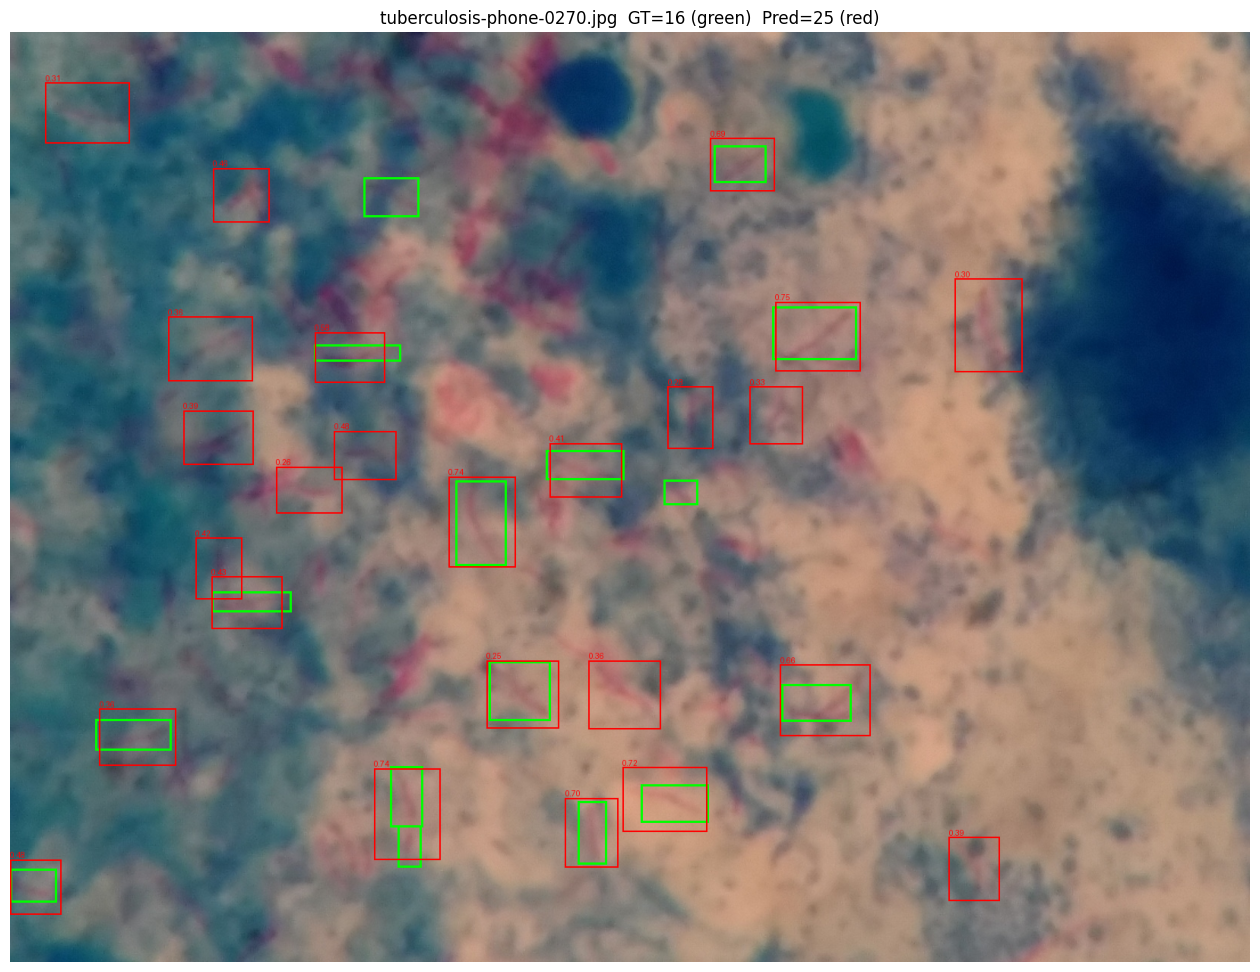

In [12]:
# Visual audit single image, untungnya sudah dapat namanya
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

img_name = "tuberculosis-phone-0270.jpg"
img_path = img_dir / img_name
lbl_path = lbl_dir / (Path(img_name).stem + ".txt")

# Re-run predict utk 1 image ini di conf=0.25 (operating point)
res = model.predict(str(img_path), imgsz=640, conf=0.25, iou=0.7, verbose=False)[0]
im = Image.open(img_path).convert("RGB")
W,H = im.size

# Draw GT (green) vs Pred (red)
draw = ImageDraw.Draw(im)
gt = cxcywh_to_xyxy(load_gt(img_path), W, H)
for b in gt:    draw.rectangle(b.tolist(), outline="lime", width=3)
for b,c in zip(res.boxes.xyxy.cpu().numpy(), res.boxes.conf.cpu().numpy()):
    draw.rectangle(b.tolist(), outline="red", width=2)
    draw.text((b[0],b[1]-12), f"{c:.2f}", fill="red")

plt.figure(figsize=(16,16)); plt.imshow(im); plt.axis("off")
plt.title(f"{img_name}  GT={len(gt)} (green)  Pred={len(res.boxes)} (red)")
plt.show()


In [13]:
# Re-run FP composition tapi filter conf >= operating point dulu
CONF_OP = 0.25  # operating point dari conf sweep / Ultralytics F1

# Filter all_preds yang sudah collected
hc_fp_dist = {"near":0,"close":0,"far":0,"wouldbe_tp":0}
hc_tp = hc_fp = 0
for p, r in zip(img_paths, results):
    W,H = Image.open(p).size
    gt   = cxcywh_to_xyxy(load_gt(p),W,H)
    bxs  = r.boxes.xyxy.cpu().numpy() if r.boxes is not None else np.zeros((0,4))
    cnf  = r.boxes.conf.cpu().numpy() if r.boxes is not None else np.zeros((0,))
    keep = cnf >= CONF_OP
    bxs, cnf = bxs[keep], cnf[keep]
    if len(gt)==0:
        hc_fp_dist["far"] += len(bxs); hc_fp += len(bxs); continue
    ious = iou_mat(bxs, gt)
    best_iou = ious.max(1) if ious.size else np.zeros(len(bxs))
    best_gt  = ious.argmax(1) if ious.size else np.zeros(len(bxs),dtype=int)
    order = np.argsort(-cnf)
    gt_taken = np.zeros(len(gt),bool); pred_tp=np.zeros(len(bxs),bool)
    for i in order:
        if best_iou[i] >= 0.5 and not gt_taken[best_gt[i]]:
            gt_taken[best_gt[i]] = True; pred_tp[i] = True
    hc_tp += int(pred_tp.sum()); hc_fp += int((~pred_tp).sum())
    gt_diam = np.sqrt(((gt[:,2]-gt[:,0])*(gt[:,3]-gt[:,1])).mean())
    gc = np.stack([(gt[:,0]+gt[:,2])/2,(gt[:,1]+gt[:,3])/2],1)
    for i in range(len(bxs)):
        if pred_tp[i]: continue
        if 0.3 <= best_iou[i] < 0.5: hc_fp_dist["wouldbe_tp"]+=1; continue
        pc = np.array([(bxs[i,0]+bxs[i,2])/2,(bxs[i,1]+bxs[i,3])/2])
        d  = np.linalg.norm(gc-pc,axis=1).min()/max(gt_diam,1e-6)
        if   d<0.5: hc_fp_dist["near"] += 1
        elif d<2.0: hc_fp_dist["close"]+= 1
        else:       hc_fp_dist["far"]  += 1

print(f"\n=== HIGH-CONF (≥{CONF_OP}) FP composition ===")
print(f"TP={hc_tp}  FP={hc_fp}  FN={total_gt-hc_tp}  P={hc_tp/(hc_tp+hc_fp):.3f}  R={hc_tp/total_gt:.3f}")
tot = max(sum(hc_fp_dist.values()),1)
for k,v in hc_fp_dist.items():
    print(f"  {k:>12}: {v:>4} ({100*v/tot:5.1f}%)")



=== HIGH-CONF (≥0.25) FP composition ===
TP=586  FP=657  FN=475  P=0.471  R=0.552
          near:   28 (  4.3%)
         close:   84 ( 12.8%)
           far:  200 ( 30.4%)
    wouldbe_tp:  345 ( 52.5%)


In [14]:
# Audit wouldbe_tp: type (a) localization slip vs (b) near-duplicate
slip = dup = 0
for p, r in zip(img_paths, results):
    W,H = Image.open(p).size
    gt  = cxcywh_to_xyxy(load_gt(p),W,H)
    bxs = r.boxes.xyxy.cpu().numpy() if r.boxes is not None else np.zeros((0,4))
    cnf = r.boxes.conf.cpu().numpy() if r.boxes is not None else np.zeros((0,))
    keep = cnf >= 0.25; bxs, cnf = bxs[keep], cnf[keep]
    if len(gt)==0 or len(bxs)==0: continue
    ious = iou_mat(bxs, gt)
    best_iou = ious.max(1); best_gt = ious.argmax(1)
    order = np.argsort(-cnf)
    gt_taken = np.zeros(len(gt), bool); pred_tp = np.zeros(len(bxs), bool)
    for i in order:
        if best_iou[i] >= 0.5 and not gt_taken[best_gt[i]]:
            gt_taken[best_gt[i]] = True; pred_tp[i] = True
    for i in range(len(bxs)):
        if pred_tp[i]: continue
        if 0.3 <= best_iou[i] < 0.5:
            if gt_taken[best_gt[i]]:  # GT-nya sudah ke-claim → duplicate
                dup += 1
            else:                      # GT belum di-claim → localization slip
                slip += 1
print(f"wouldbe_tp breakdown: localization-slip={slip}  near-duplicate={dup}")
print(f"  slip%  = {100*slip/(slip+dup):.1f}%  → NWD addressable")
print(f"  dup%   = {100*dup/(slip+dup):.1f}%  → NMS / Soft-NMS / WBF addressable")


wouldbe_tp breakdown: localization-slip=336  near-duplicate=9
  slip%  = 97.4%  → NWD addressable
  dup%   = 2.6%  → NMS / Soft-NMS / WBF addressable
